# AN2DL - Homework 1

## 1 - Libraries and Dataset Import


In [1]:
# In this notebook you will only find comments related to new/modified code
# Please refere to our initial notebook FORmidable_basic_model for all commented sections
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import cv2
import os

os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
import keras as tfk
from keras import layers as tfkl
from keras import applications as tfka
from keras_cv import layers as kcvl
from keras import mixed_precision

tf.config.optimizer.set_jit(True)

print("GPUs Available: ", tf.config.list_physical_devices('GPU'))
print(f"TensorFlow version {tf.__version__}")

np.random.seed(42)
tf.random.set_seed(42)

GPUs Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
TensorFlow version 2.17.1


In [2]:
data = np.load('/kaggle/input/a2ndl-hom1-dataset/training_set.npz')

X = data['images']
y = data['labels']
#X = X[:3000]
#y = y[:3000]

print(X.shape, y.shape)

(13759, 96, 96, 3) (13759, 1)


## 2 - Checking for missing, duplicate values and class distribution

In [3]:
missing_targets = np.isnan(y.flatten()).any()

if not missing_targets :
    print("There are no missing or NaN values in the target vector.")

There are no missing or NaN values in the target vector.


In [4]:
# Duplicates count and removal
reshaped_X = X.reshape(X.shape[0], -1)
unique_X, unique_indices = np.unique(reshaped_X, axis=0, return_index=True)

X_unique = X[unique_indices]
y_unique = y[unique_indices]

print(f'Labels reduced from {len(y)} to {len(y_unique)}')

X = X_unique
y = y_unique

Labels reduced from 13759 to 11953


In [5]:
labels = {0:'Basophil', 1:'Eosinophil', 2:'Erythroblast', 3:'Immature granulocytes', 4:'Lymphocyte', 5:'Monocyte', 6:'Neutrophil', 7:'Platelet'}

# Class plotting already shown in FORmidable_basic_model notebook

## 3 - Split dataset into Train, Test and Validation sets while maintaining the distribution

In [6]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.1, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.05, stratify=y_train_val)

print("Training Data Shape:", X_train.shape)
print("Training Label Shape:", y_train.shape)
print("Test Data Shape:", X_test.shape)
print("Test Label Shape:", y_test.shape)
print("Validation Data Shape:", X_val.shape)
print("Validation Label Shape:", y_val.shape)

y_train = tfk.utils.to_categorical(y_train)
y_val = tfk.utils.to_categorical(y_val)
y_test = tfk.utils.to_categorical(y_test)

Training Data Shape: (10219, 96, 96, 3)
Training Label Shape: (10219, 1)
Test Data Shape: (1196, 96, 96, 3)
Test Label Shape: (1196, 1)
Validation Data Shape: (538, 96, 96, 3)
Validation Label Shape: (538, 1)


## 4 - Image Augmentation

In [7]:
# Here we define the augmentation pipeline, custom augmentation layers,
# and the functions to apply the pipeline to the dataset and visualize the augmented images.
import tensorflow as tf
from keras_cv import layers as kcvl
from tensorflow.keras.layers import Resizing # type: ignore
import matplotlib.pyplot as plt

# Augmentation pipeline parameters
value_range = (0, 255)  # Range of pixel values in the images

# Define the augmentation layers
enhancement_layers = [
    kcvl.RandAugment(value_range=value_range, magnitude=0.2, magnitude_stddev=0.1),
    #kcvl.GridMask(ratio_factor=0.4),
    #kcvl.RandomSharpness(factor=0.2, value_range=value_range)
]

# Custom function to add Gaussian noise
def add_gaussian_noise(images, mean=0.0, stddev=20):
    noise = tf.random.normal(shape=tf.shape(images), mean=mean, stddev=stddev, dtype=tf.float32)
    noisy_images = images + noise
    return tf.clip_by_value(noisy_images, 0.0, 255.0)

# Define the augmentation pipeline
pipeline = kcvl.RandomAugmentationPipeline(
    layers=enhancement_layers,
    augmentations_per_image=4
)

def apply_pipeline(inputs):
    inputs["images"] = pipeline(inputs["images"])  # Apply RandomAugmentationPipeline
    #inputs["images"] = add_gaussian_noise(inputs["images"])  # Add custom Gaussian Noise
    return inputs

# Function to plot augmented images for visualization
def plot_augmented_images(X_train, y_train, num_images, num_augmentations=5):
    batch = X_train[:num_images]  # Take a batch of images for visualization
    labels_batch = y_train[:num_images]

    fig, axes = plt.subplots(num_augmentations + 1, num_images, figsize=(20, 10))  # 4 rows, 10 columns

    # Display original images in the first row
    for i in range(num_images):
        original_image = batch[i].astype("uint8")  # Convert to uint8 for display
        axes[0, i].imshow(original_image)
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original", fontsize=12)
        else:
            axes[0, i].set_title("")

    # Display augmentations in subsequent rows
    for j in range(num_augmentations):
        augmented_batch = apply_pipeline({
            "images": tf.convert_to_tensor(batch),
            "labels": tf.convert_to_tensor(labels_batch, dtype=tf.float32)
        })
        for i in range(num_images):
            augmented_image = tf.clip_by_value(augmented_batch["images"][i], 0, 255)  # Ensure values are in display range
            axes[j + 1, i].imshow(augmented_image.numpy().astype("uint8"))
            axes[j + 1, i].axis("off")
            if i == 0:
                axes[j + 1, i].set_title(f"Augmentation {j + 1}", fontsize=12)
            else:
                axes[j + 1, i].set_title("")

    plt.tight_layout()
    plt.show()

# Function to create the training dataset pipeline with augmentation and normalization
def create_train_dataset(X_train, y_train, batch_size, target_size):
    normalization = 127.5
    range = 1
    resize_layer = Resizing(target_size[0], target_size[1], interpolation='bicubic')

    train_dataset = (
        tf.data.Dataset.from_tensor_slices((X_train, y_train))
        .batch(batch_size)
        .map(lambda x, y: (apply_pipeline({"images": x, "labels": tf.cast(y, tf.float32)})["images"], y), num_parallel_calls=tf.data.AUTOTUNE)
        .map(lambda x, y: (resize_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)  # Apply bicubic resizing
        .map(lambda x, y: ((x / normalization) - range, y), num_parallel_calls=tf.data.AUTOTUNE)  # Normalize images
        .prefetch(tf.data.AUTOTUNE)
    )
    return train_dataset

# Function to create the validation dataset pipeline with resizing and normalization
def create_val_dataset(X_val, y_val, batch_size, target_size):
    normalization = 127.5
    range = 1
    resize_layer = Resizing(target_size[0], target_size[1], interpolation='bicubic')

    val_dataset = (
        tf.data.Dataset.from_tensor_slices((X_val, y_val))
        .batch(batch_size)
        .map(lambda x, y: (resize_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)  # Apply bicubic resizing
        .map(lambda x, y: ((x / normalization) - range, y), num_parallel_calls=tf.data.AUTOTUNE)  # Normalize images
        .prefetch(tf.data.AUTOTUNE)
    )
    return val_dataset

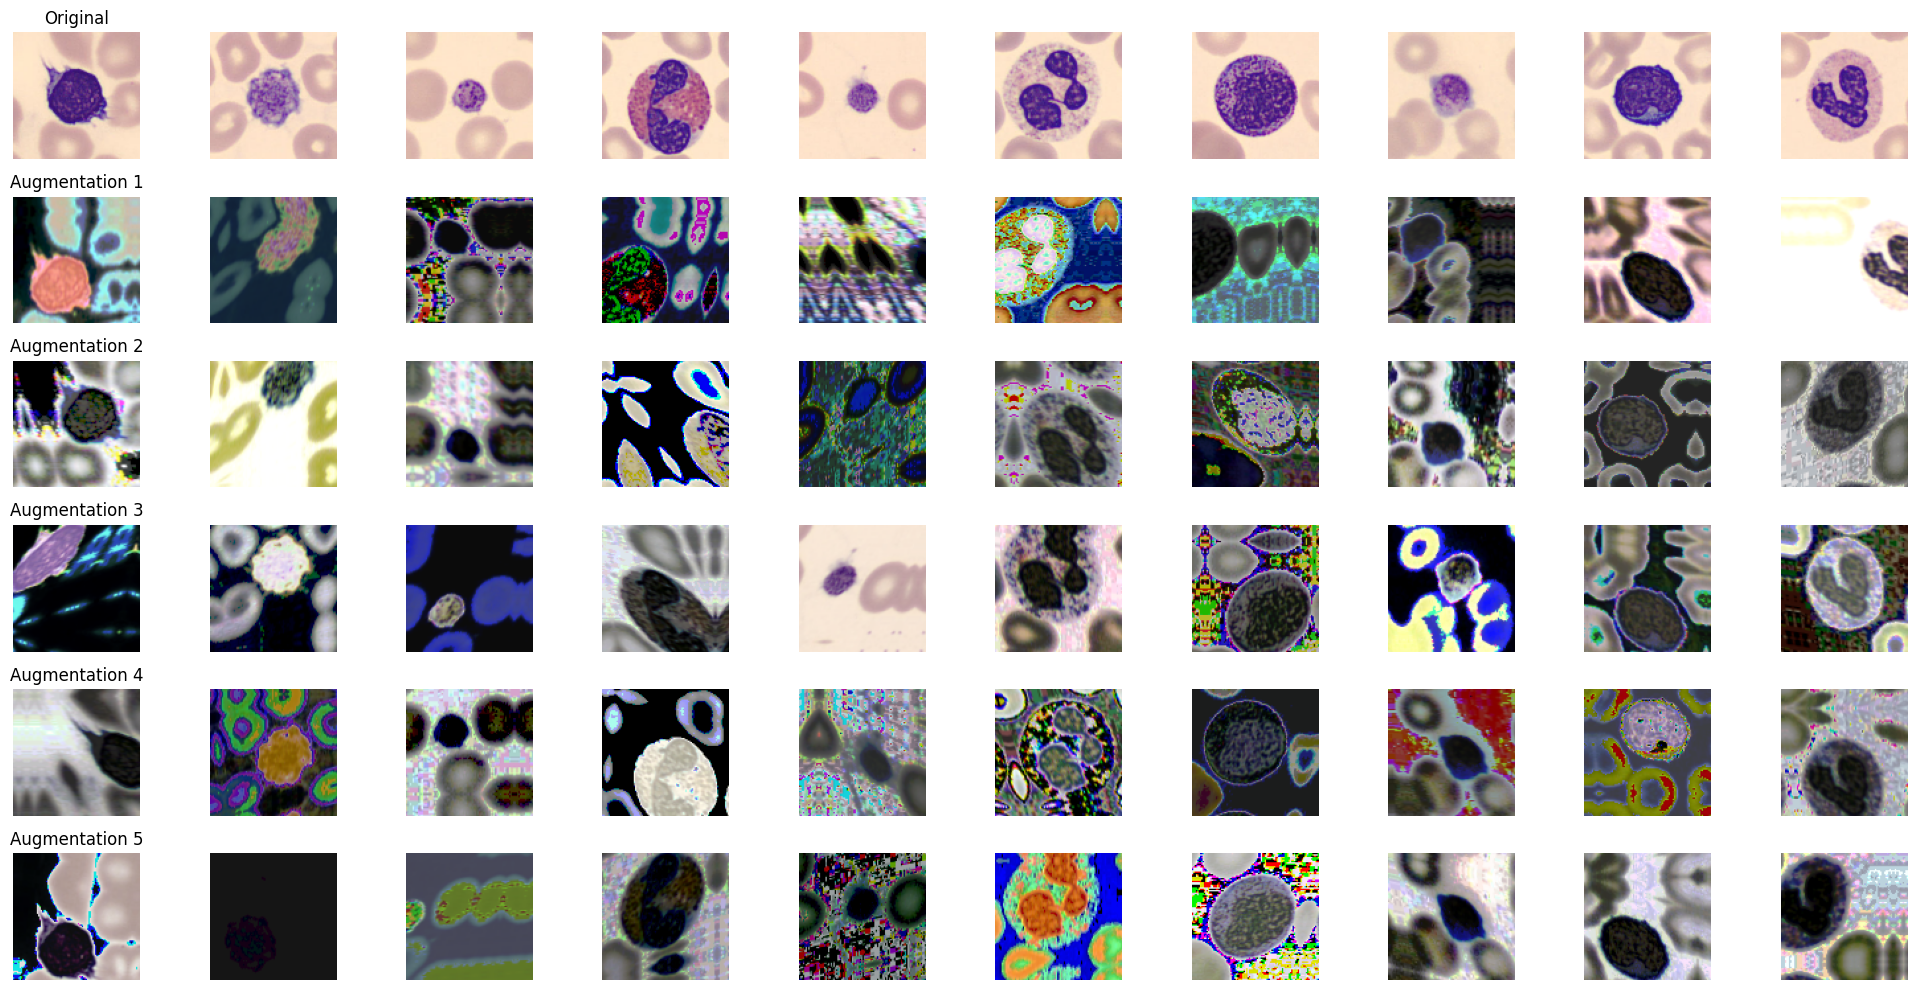

In [8]:
batch_size = 32
target_size = (224, 224)  # Desired size to feed the MobileNetV2 pre-trained model

plot_augmented_images(X_train, y_train, num_images=10)

train_dataset = create_train_dataset(X_train, y_train, batch_size, target_size)
val_dataset = create_val_dataset(X_val, y_val, batch_size, target_size)

# 5. Training

In [9]:
mixed_precision.set_global_policy('mixed_float16')

def build_model(input_shape, output_shape, learning_rate, fine_tune_at=30):
    # Loading MobileNetV2 as the base model
    mnv2_model = tfka.MobileNetV2(
        include_top=False, # To define our custom head
        input_shape=input_shape,
        weights="imagenet", # Here the only allowed trained weights in our competition
        alpha=1.0 # Include alpha% of the width of the model, lower it if you want the training to be faster 
    )

    # Custom head for our dataset
    inputs = tfkl.Input(shape=input_shape, name="Input")
    x = mnv2_model(inputs, training=False)
    x = tfkl.GlobalAveragePooling2D(name="global_avg_pool")(x) # Same as in the original MNV2 head
    x = tfkl.Dropout(0.2, name="dropout")(x)  # Low dropout rate for lighter regularization
    outputs = tfkl.Dense(units=output_shape, dtype='float32', activation="softmax", name="softmax")(x)

    model = tfk.Model(inputs, outputs, name="MobileNetV2_pretrained")

    loss = tfk.losses.CategoricalCrossentropy()

    # Applying fine-tuning to unfreeze part of the base model and so to adapt more training weights on our dataset
    mnv2_model.trainable = True  # Unfreeze the whole base model
    for layer in mnv2_model.layers[:-fine_tune_at]:
        layer.trainable = False  # Keep all layers except top fine_tune_at frozen

    # Compiling the model with Lion optimizer
    optimizer = tfk.optimizers.Lion(
        learning_rate=learning_rate,  # Uses our chosen stable starting learning rate for optimization
        beta_1=0.9,  # Momentum parameter to control the contribution of past gradients
        beta_2=0.99,  # Controls the decay rate of the moving average of squared gradients
        weight_decay=1e-4  # Helps prevent overfitting by penalizing large weights; 1e-4 for good balance between convergence stability and speed
    )

    model.compile(loss=loss, optimizer=optimizer, metrics=['accuracy'])
    return model

Train batch images shape: (32, 224, 224, 3)
Train batch labels shape: (32, 8)
Input Shape: (224, 224, 3)
Output Shape: 8
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_pretrained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ Input (InputLayer)                  │ (None, 224, 224, 3)          │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ mobilenetv2_1.00_224 (Functional)   │ (None, 7, 7, 1280)           │     2,257,984 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ global_avg_pool                     │ (None, 1280)                 │             0 │    -    │
│ (GlobalAveragePooling2D)            │                              │               │         │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dropout (Dropout)                   │ (None, 1280)                 │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ cast_1 (Cast)                       │ (None, 1280)                 │             0 │    -    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ softmax (Dense)                     │ (None, 8)                    │        10,248 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 2,268,232 (8.65 MB)

 Trainable params: 1,536,648 (5.86 MB)

 Non-trainable params: 731,584 (2.79 MB)

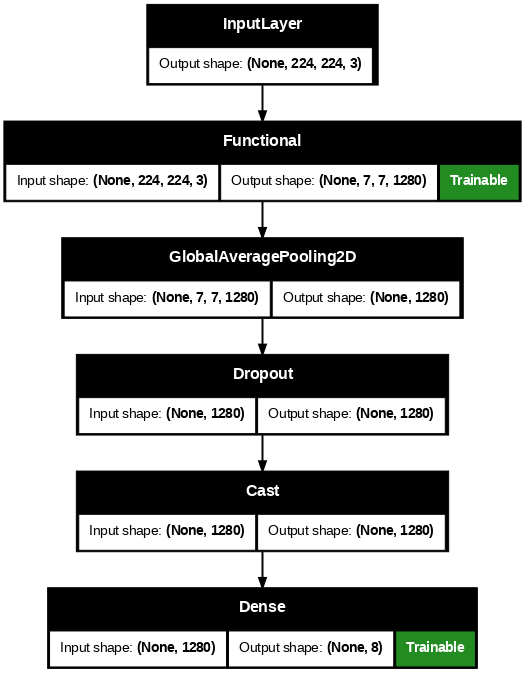

In [10]:
for batch_images, batch_labels in train_dataset.take(1):
    print("Train batch images shape:", batch_images.shape)
    print("Train batch labels shape:", batch_labels.shape)
    input_shape = batch_images.shape[1:]
    output_shape = batch_labels.shape[1]
    print("Input Shape:", input_shape)
    print("Output Shape:", output_shape)

initial_learning_rate = 1e-4

model = build_model(input_shape, output_shape, initial_learning_rate)
model.summary(expand_nested=False, show_trainable=True)
tfk.utils.plot_model(model, expand_nested=False, show_trainable=True, show_shapes=True, dpi=70)

In [11]:
epochs = 100 # Setting a limited number of epochs for the incoming early stopping, due to foreseen overfitting

early_stopping = tfk.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=15, restore_best_weights=True, verbose=1)
reduce_lr = tfk.callbacks.ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.3, patience=8, min_lr=1e-6, verbose=1)

In [12]:
start_time = time.time()

history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=[early_stopping, reduce_lr]
    ).history

print("--- %s seconds ---" % (time.time() - start_time))

final_val_accuracy = round(max(history['val_accuracy'])* 100, 2)
print(f'Final validation accuracy: {final_val_accuracy}%')

model_filename = 'MNV2_pretrained.keras'
print('Saving to', model_filename)
model.save(model_filename)

Epoch 1/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 151s 380ms/step - accuracy: 0.5576 - loss: 1.2022 - val_accuracy: 0.4033 - val_loss: 6.6108 - learning_rate: 1.0000e-04
Epoch 2/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 115s 339ms/step - accuracy: 0.7733 - loss: 0.6037 - val_accuracy: 0.5743 - val_loss: 2.9993 - learning_rate: 1.0000e-04
Epoch 3/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 113s 332ms/step - accuracy: 0.8154 - loss: 0.5200 - val_accuracy: 0.4963 - val_loss: 2.6947 - learning_rate: 1.0000e-04
Epoch 4/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 113s 333ms/step - accuracy: 0.8287 - loss: 0.4813 - val_accuracy: 0.7491 - val_loss: 1.2951 - learning_rate: 1.0000e-04
Epoch 5/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 117s 343ms/step - accuracy: 0.8430 - loss: 0.4544 - val_accuracy: 0.8439 - val_loss: 0.5328 - learning_rate: 1.0000e-04
Epoch 6/100
320/320 ━━━━━━━━━━━━━━━━━━━━ 116s 342ms/step - accuracy: 0.8532 - loss: 0.4140 - val_accuracy: 0.8253 - val_loss: 0.7695 - learning_rate: 1.0000e-04
Epoch 7/100
320/320 ━━━━━━━━━━━━━━

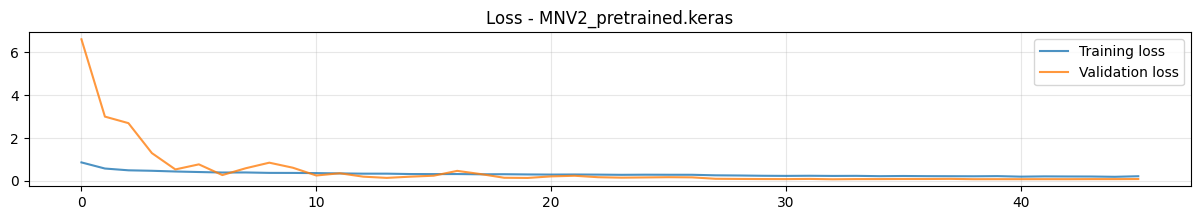

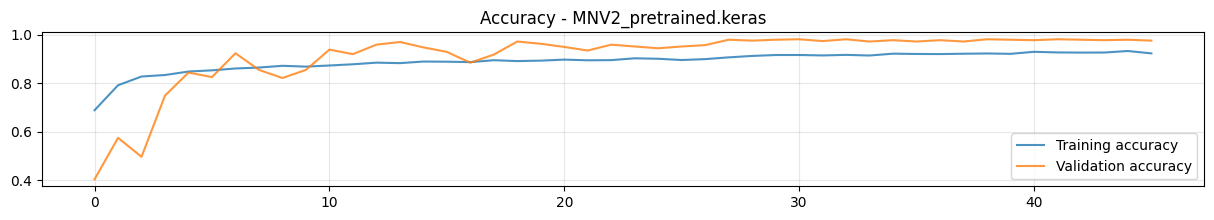

In [13]:
plt.figure(figsize=(15, 2))
plt.plot(history['loss'], label='Training loss', alpha=.8)
plt.plot(history['val_loss'], label='Validation loss', alpha=.8)
plt.title(f'Loss - {model_filename}')
plt.legend()
plt.grid(alpha=.3)

plt.figure(figsize=(15, 2))
plt.plot(history['accuracy'], label='Training accuracy', alpha=.8)
plt.plot(history['val_accuracy'], label='Validation accuracy', alpha=.8)
plt.title(f'Accuracy - {model_filename}')
plt.legend()
plt.grid(alpha=.3)
plt.show()


# 6. Evaluating the model on the local test set

(1196, 224, 224, 3) (1196, 8)
Predictions Shape: (1196, 8)
Accuracy score over the test set: 0.954
Precision score over the test set: 0.9565
Recall score over the test set: 0.954
F1 score over the test set: 0.9542


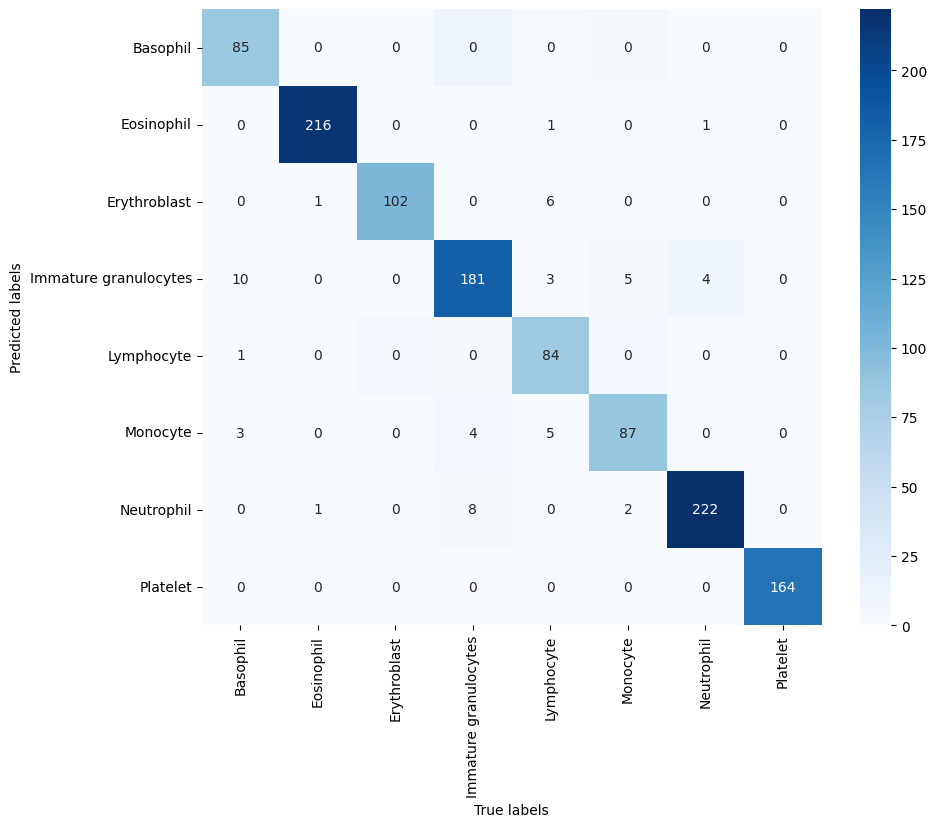

In [14]:
model = tfk.models.load_model(model_filename)

# Apply normalization and resizing to the test data directly, as done in the model.py submission file
X_normalized = (X_test / 127.5).astype('float32') - 1
X_resized = np.array([cv2.resize(img, target_size, interpolation=cv2.INTER_CUBIC) for img in X_normalized])
print(X_resized.shape, y_test.shape)

predictions = model.predict(X_resized, verbose=0)

print("Predictions Shape:", predictions.shape)

pred_classes = np.argmax(predictions, axis=-1)
true_classes = np.argmax(y_test, axis=-1)

accuracy = accuracy_score(true_classes, pred_classes)
print(f'Accuracy score over the test set: {round(accuracy, 4)}')

precision = precision_score(true_classes, pred_classes, average='weighted')
print(f'Precision score over the test set: {round(precision, 4)}')

recall = recall_score(true_classes, pred_classes, average='weighted')
print(f'Recall score over the test set: {round(recall, 4)}')

f1 = f1_score(true_classes, pred_classes, average='weighted')
print(f'F1 score over the test set: {round(f1, 4)}')

cm = confusion_matrix(true_classes, pred_classes)

annot = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm.T, annot=annot, fmt='', xticklabels=list(labels.values()), yticklabels=list(labels.values()), cmap='Blues')
plt.xlabel('True labels')
plt.ylabel('Predicted labels')
plt.show()

# 7. Evaluating the model on the hidden competition test set

(1712, 224, 224, 3) (1712, 1)


Model: "MobileNetV2_pretrained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)                   │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_avg_pool                      │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ cast_5 (Cast)                        │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ softmax (Dense)                      │ (None, 8)                   │          10,248 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,804,886 (14.51 MB)

 Trainable params: 1,536,648 (5.86 MB)

 Non-trainable params: 731,584 (2.79 MB)

 Optimizer params: 1,536,654 (5.86 MB)

Accuracy score over the test set: 0.8697
Precision score over the test set: 0.8751
Recall score over the test set: 0.8697
F1 score over the test set: 0.8704


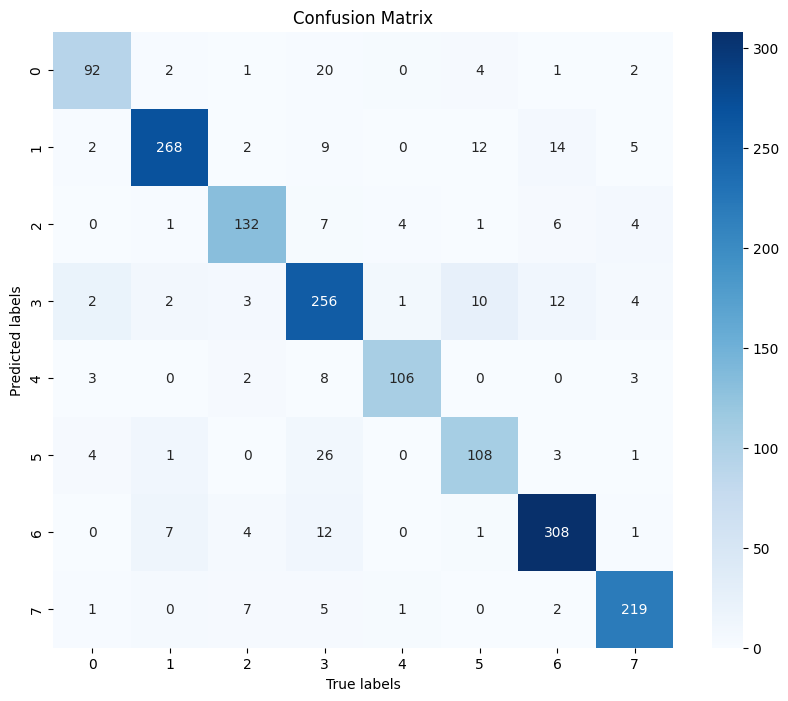

In [15]:
import numpy as np
import cv2
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras as tfk

# Load the data from the npz file
data = np.load('/kaggle/input/test-set-1/test_set_1.npz')

# Extract test images and labels from the npz file
X_test = data['images']
y_test = data['labels']

# Preprocessing the images (normalize and resize)
X_normalized = (X_test / 127.5).astype('float32') - 1  # Normalize to [-1, 1]
target_size = (224, 224)  # Size expected by MobileNetV2
X_resized = np.array([cv2.resize(img, target_size, interpolation=cv2.INTER_CUBIC) for img in X_normalized])

# Print the shapes of the processed images and labels
print(X_resized.shape, y_test.shape)

# Load the trained model (make sure it's already saved or replace with the correct path)
#model_filename = '/kaggle/input/mnv2-pretrained/MNV2_pretrained.keras'  # Provide the correct path here
model = tfk.models.load_model(model_filename)
model.summary()
# Make predictions
predictions = model.predict(X_resized, verbose=0)

# If the output shape of predictions is (n_samples, n_classes), get the predicted class
if len(predictions.shape) == 2:
    pred_classes = np.argmax(predictions, axis=1)


true_classes = y_test  # If labels are already in class indices form

# Compute performance metrics
accuracy = accuracy_score(true_classes, pred_classes)
precision = precision_score(true_classes, pred_classes, average='weighted')
recall = recall_score(true_classes, pred_classes, average='weighted')
f1 = f1_score(true_classes, pred_classes, average='weighted')

# Print the results
print(f'Accuracy score over the test set: {round(accuracy, 4)}')
print(f'Precision score over the test set: {round(precision, 4)}')
print(f'Recall score over the test set: {round(recall, 4)}')
print(f'F1 score over the test set: {round(f1, 4)}')

# Confusion matrix
cm = confusion_matrix(true_classes, pred_classes)

# Annotate confusion matrix with counts
annot = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm.T, annot=annot, fmt='', xticklabels=list(range(len(cm))), yticklabels=list(range(len(cm))), cmap='Blues')
plt.xlabel('True labels')
plt.ylabel('Predicted labels')
plt.title('Confusion Matrix')
plt.show()
